# Lab 2 - Cost-Complexity Pruning

**Phần phụ trách: Thái Kiệt**

Mục tiêu là nhận diện overfitting của baseline, lựa chọn `criterion` và `ccp_alpha` bằng stratified five-fold F1 cross-validation, rồi đánh giá hiệu suất mô hình theo kích thước cây.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').is_dir() and (candidate / 'data' / 'bank-full.csv').is_file():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc của dự án.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TREES_DIR = PROJECT_ROOT / 'outputs' / 'trees'

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
print('Đã nhận diện thư mục gốc của dự án.')

Đã nhận diện thư mục gốc của dự án.


In [2]:
from src.pruning_experiment import run_pruning_workflow

required_artifacts = [
    RESULTS_DIR / 'kiet_pruning_validation.csv',
    RESULTS_DIR / 'kiet_pruning_test_comparison.csv',
    RESULTS_DIR / 'kiet_pruning_metrics.json',
    TREES_DIR / 'kiet_pruned_gini_model.joblib',
    TREES_DIR / 'kiet_pruned_entropy_model.joblib',
]
missing = [path for path in required_artifacts if not path.is_file()]
if missing:
    print('Thiếu artifacts, bắt đầu chạy lại thí nghiệm pruning...')
    workflow_summary = run_pruning_workflow()
    display(workflow_summary)
else:
    print('Đã tải các kết quả thí nghiệm có sẵn.')

validation = pd.read_csv(RESULTS_DIR / 'kiet_pruning_validation.csv')
comparison = pd.read_csv(RESULTS_DIR / 'kiet_pruning_test_comparison.csv')
metrics_payload = json.loads(
    (RESULTS_DIR / 'kiet_pruning_metrics.json').read_text(encoding='utf-8')
)
print(f'Số cấu hình validation: {len(validation)}')
print(f'Số mô hình test: {len(comparison)}')

Đã tải các kết quả thí nghiệm có sẵn.
Số cấu hình validation: 80
Số mô hình test: 4


## 1. Thiết kế thí nghiệm

- Giữ nguyên stratified train/test 80%/20% và random_state = 42 của nhóm.
- Toàn bộ tập train chính thức được đánh giá bằng stratified five-fold CV.
- Mỗi criterion dùng cùng lưới `ccp_alpha` cố định, không phụ thuộc nhãn.
- Chọn cấu hình bằng mean F1 của lớp `yes`; tie-break theo Recall rồi độ nhỏ của cây.
- Tập test chỉ dùng để đánh giá sau khi cấu hình đã được khóa.

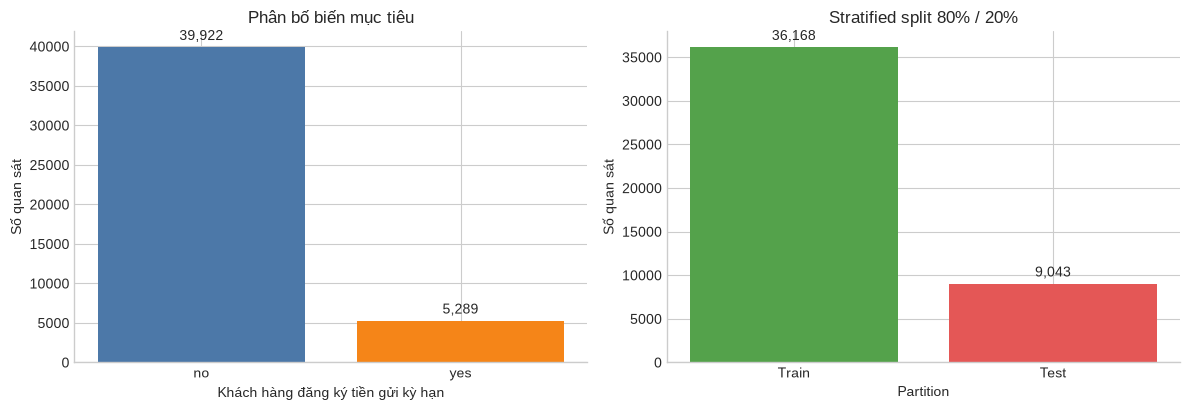

Partition,Rows,Positive rate
Train,"36,168",11.698%
Test,"9,043",11.700%


In [3]:
from src.data import load_and_split_data
from src.experiment_contract import RANDOM_STATE, TEST_SIZE

split = load_and_split_data(test_size=TEST_SIZE, random_state=RANDOM_STATE)
all_targets = pd.concat([split.y_train, split.y_test]).map({0: 'no', 1: 'yes'})
class_counts = all_targets.value_counts().reindex(['no', 'yes'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
bars = axes[0].bar(class_counts.index, class_counts.values, color=['#4C78A8', '#F58518'])
axes[0].set_title('Phân bố biến mục tiêu')
axes[0].set_xlabel('Khách hàng đăng ký tiền gửi kỳ hạn')
axes[0].set_ylabel('Số quan sát')
axes[0].bar_label(bars, labels=[f'{value:,}' for value in class_counts.values], padding=3)

split_sizes = pd.Series({'Train': len(split.y_train), 'Test': len(split.y_test)})
bars = axes[1].bar(split_sizes.index, split_sizes.values, color=['#54A24B', '#E45756'])
axes[1].set_title('Stratified split 80% / 20%')
axes[1].set_xlabel('Partition')
axes[1].set_ylabel('Số quan sát')
axes[1].bar_label(bars, labels=[f'{value:,}' for value in split_sizes.values], padding=3)

for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

display(pd.DataFrame({
    'Partition': ['Train', 'Test'],
    'Rows': [len(split.y_train), len(split.y_test)],
    'Positive rate': [split.y_train.mean(), split.y_test.mean()],
}).style.format({'Rows': '{:,}', 'Positive rate': '{:.3%}'}).hide(axis='index'))

## 2. Vấn đề của baseline

Cây baseline không giới hạn đạt Accuracy train bằng 1.0 nhưng thấp hơn rõ rệt trên test. Độ sâu 34 và 2,876 lá cho thấy cây đã ghi nhớ nhiều chi tiết của tập train. Cost-Complexity Pruning thêm mức phạt theo số lá để cân bằng sai số và độ phức tạp:

**R_alpha(T) = R(T) + alpha × số lá của T**

In [4]:
selected_rows = []
for criterion, values in metrics_payload['selected_by_criterion'].items():
    selected_rows.append({
        'Criterion': criterion.title(),
        'ccp_alpha': values['ccp_alpha'],
        'Mean CV F1': values['mean_cv_f1'],
        'Std CV F1': values['std_cv_f1'],
        'Mean CV Recall': values['mean_cv_recall'],
        'Depth': values['depth'],
        'Leaves': values['leaves'],
        'Nodes': values['nodes'],
    })

selection_table = pd.DataFrame(selected_rows)
display(
    selection_table.style
    .format({
        'ccp_alpha': '{:.9f}',
        'Mean CV F1': '{:.4f}',
        'Std CV F1': '{:.4f}',
        'Mean CV Recall': '{:.4f}',
        'Leaves': '{:,}',
        'Nodes': '{:,}',
    })
    .background_gradient(subset=['Mean CV F1'], cmap='Blues')
    .hide(axis='index')
)
print(f"Criterion được khóa theo mean CV F1: {metrics_payload['selected_criterion'].title()}")


Criterion,ccp_alpha,Mean CV F1,Std CV F1,Mean CV Recall,Depth,Leaves,Nodes
Entropy,0.000216866,0.5370,0.0166,0.4911,19,143,285
Gini,0.000110705,0.5336,0.0242,0.4869,18,101,201


Criterion được khóa theo mean CV F1: Entropy


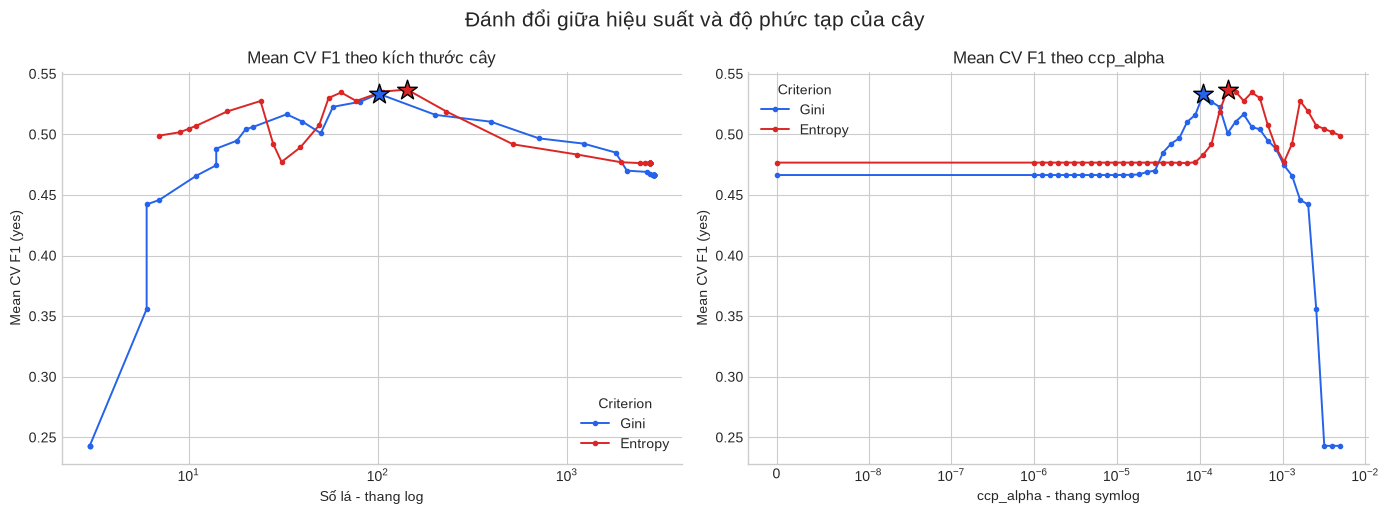

In [5]:
colors = {'gini': '#2563EB', 'entropy': '#DC2626'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for criterion in ['gini', 'entropy']:
    group = validation.loc[validation['criterion'].eq(criterion)].sort_values('ccp_alpha')
    selected = metrics_payload['selected_by_criterion'][criterion]
    axes[0].plot(
        group['leaves'], group['mean_cv_f1'], marker='o', markersize=3,
        linewidth=1.4, label=criterion.title(), color=colors[criterion]
    )
    axes[0].scatter(
        selected['leaves'], selected['mean_cv_f1'], marker='*', s=220,
        color=colors[criterion], edgecolor='black', zorder=5
    )
    axes[1].plot(
        group['ccp_alpha'], group['mean_cv_f1'], marker='o', markersize=3,
        linewidth=1.4, label=criterion.title(), color=colors[criterion]
    )
    axes[1].scatter(
        selected['ccp_alpha'], selected['mean_cv_f1'], marker='*', s=220,
        color=colors[criterion], edgecolor='black', zorder=5
    )

axes[0].set_xscale('log')
axes[0].set_title('Mean CV F1 theo kích thước cây')
axes[0].set_xlabel('Số lá - thang log')
axes[0].set_ylabel('Mean CV F1 (yes)')
axes[1].set_xscale('symlog', linthresh=1e-8)
axes[1].set_title('Mean CV F1 theo ccp_alpha')
axes[1].set_xlabel('ccp_alpha - thang symlog')
axes[1].set_ylabel('Mean CV F1 (yes)')
for axis in axes:
    axis.legend(title='Criterion')
    axis.spines[['top', 'right']].set_visible(False)
fig.suptitle('Đánh đổi giữa hiệu suất và độ phức tạp của cây', fontsize=15)
fig.tight_layout()
plt.show()

## 3. So sánh cuối trên tập test

Hai mô hình unpruned giúp tách ảnh hưởng của criterion. Hai mô hình pruned cho thấy tác động kết hợp của criterion và ccp_alpha.

In [6]:
display_columns = [
    'model', 'criterion', 'ccp_alpha', 'accuracy', 'error_rate',
    'precision', 'recall', 'f1_score', 'roc_auc', 'depth', 'leaves', 'nodes'
]
pretty_names = {
    'model': 'Model', 'criterion': 'Criterion', 'ccp_alpha': 'ccp_alpha',
    'accuracy': 'Accuracy', 'error_rate': 'Error rate',
    'precision': 'Precision yes', 'recall': 'Recall yes',
    'f1_score': 'F1 yes', 'roc_auc': 'ROC-AUC',
    'depth': 'Depth', 'leaves': 'Leaves', 'nodes': 'Nodes'
}
comparison_pretty = comparison[display_columns].rename(columns=pretty_names)
display(
    comparison_pretty.style
    .format({
        'ccp_alpha': '{:.9f}', 'Accuracy': '{:.4f}', 'Error rate': '{:.4f}',
        'Precision yes': '{:.4f}', 'Recall yes': '{:.4f}', 'F1 yes': '{:.4f}',
        'ROC-AUC': '{:.4f}', 'Leaves': '{:,}', 'Nodes': '{:,}'
    })
    .background_gradient(subset=['Accuracy', 'F1 yes', 'ROC-AUC'], cmap='Greens')
    .hide(axis='index')
)

Model,Criterion,ccp_alpha,Accuracy,Error rate,Precision yes,Recall yes,F1 yes,ROC-AUC,Depth,Leaves,Nodes
Baseline (unpruned),gini,0.000000000,0.8737,0.1263,0.4611,0.4707,0.4659,0.6989,34,"2,876","5,751"
Unpruned Entropy,entropy,0.000000000,0.8833,0.1167,0.5015,0.4858,0.4935,0.7109,37,"2,744","5,487"
Pruned Gini,gini,0.000110705,0.9005,0.0995,0.5973,0.4584,0.5187,0.9067,18,101,201
Pruned Entropy,entropy,0.000216866,0.9045,0.0955,0.6036,0.5340,0.5667,0.9114,19,143,285


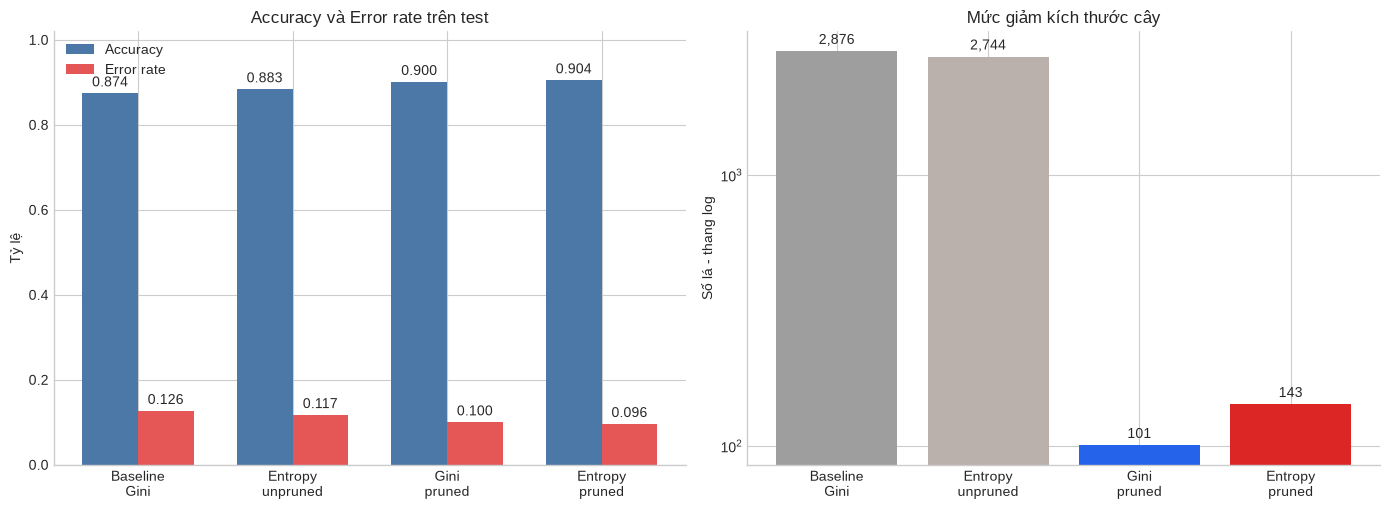

In [7]:
labels = ['Baseline\nGini', 'Entropy\nunpruned', 'Gini\npruned', 'Entropy\npruned']
x = np.arange(len(comparison))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
accuracy_bars = axes[0].bar(
    x - width / 2, comparison['accuracy'], width, label='Accuracy', color='#4C78A8'
)
error_bars = axes[0].bar(
    x + width / 2, comparison['error_rate'], width, label='Error rate', color='#E45756'
)
axes[0].bar_label(accuracy_bars, fmt='%.3f', padding=3)
axes[0].bar_label(error_bars, fmt='%.3f', padding=3)
axes[0].set_xticks(x, labels)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Tỷ lệ')
axes[0].set_title('Accuracy và Error rate trên test')
axes[0].legend()

leaf_bars = axes[1].bar(x, comparison['leaves'], color=['#9E9E9E', '#BAB0AC', '#2563EB', '#DC2626'])
axes[1].bar_label(leaf_bars, labels=[f'{value:,}' for value in comparison['leaves']], padding=3)
axes[1].set_xticks(x, labels)
axes[1].set_yscale('log')
axes[1].set_ylabel('Số lá - thang log')
axes[1].set_title('Mức giảm kích thước cây')

for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Confusion Matrix

Accuracy tổng thể chưa đủ vì lớp yes là lớp thiểu số. Confusion Matrix cho thấy rõ số khách hàng đăng ký được phát hiện và số dự đoán sai.

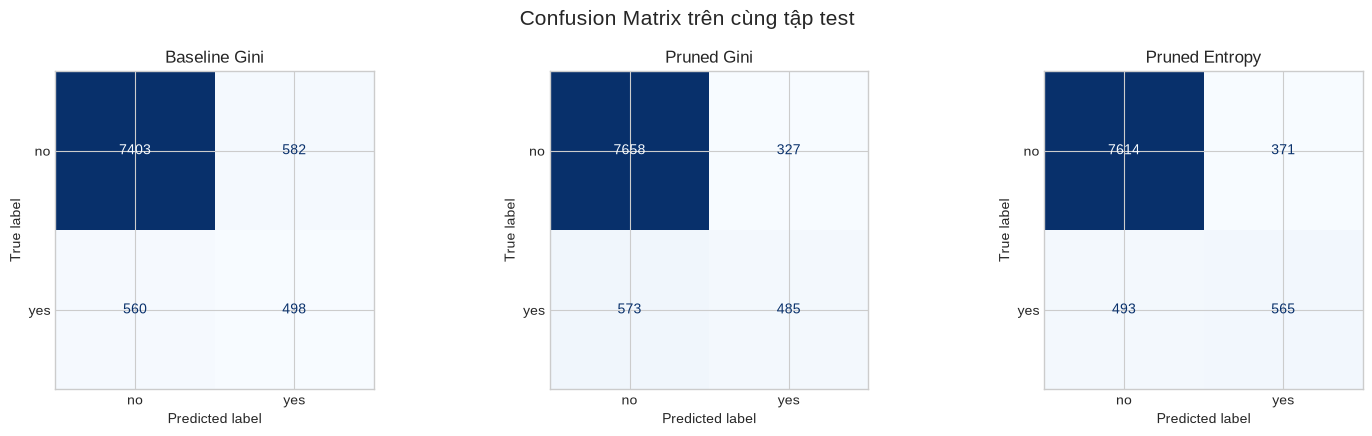

In [8]:
from src.preprocessing import build_preprocessing_pipeline
from src.pruning_experiment import tree_parameters

preprocessing = build_preprocessing_pipeline()
X_train_processed = preprocessing.fit_transform(split.X_train)
X_test_processed = preprocessing.transform(split.X_test)

baseline_model = DecisionTreeClassifier(**tree_parameters('gini', 0.0))
baseline_model.fit(X_train_processed, split.y_train)
models = {
    'Baseline Gini': baseline_model,
    'Pruned Gini': joblib.load(TREES_DIR / 'kiet_pruned_gini_model.joblib'),
    'Pruned Entropy': joblib.load(TREES_DIR / 'kiet_pruned_entropy_model.joblib'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for axis, (name, model) in zip(axes, models.items()):
    predictions = model.predict(X_test_processed)
    matrix = confusion_matrix(split.y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=['no', 'yes']).plot(
        ax=axis, cmap='Blues', colorbar=False, values_format='d'
    )
    axis.set_title(name)
fig.suptitle('Confusion Matrix trên cùng tập test', fontsize=15)
fig.tight_layout()
plt.show()

## 5. Cấu trúc cây sau pruning

Hình chỉ hiển thị các tầng đầu để đọc được nhãn. Depth, leaves và nodes trong bảng được tính trên toàn bộ cây.

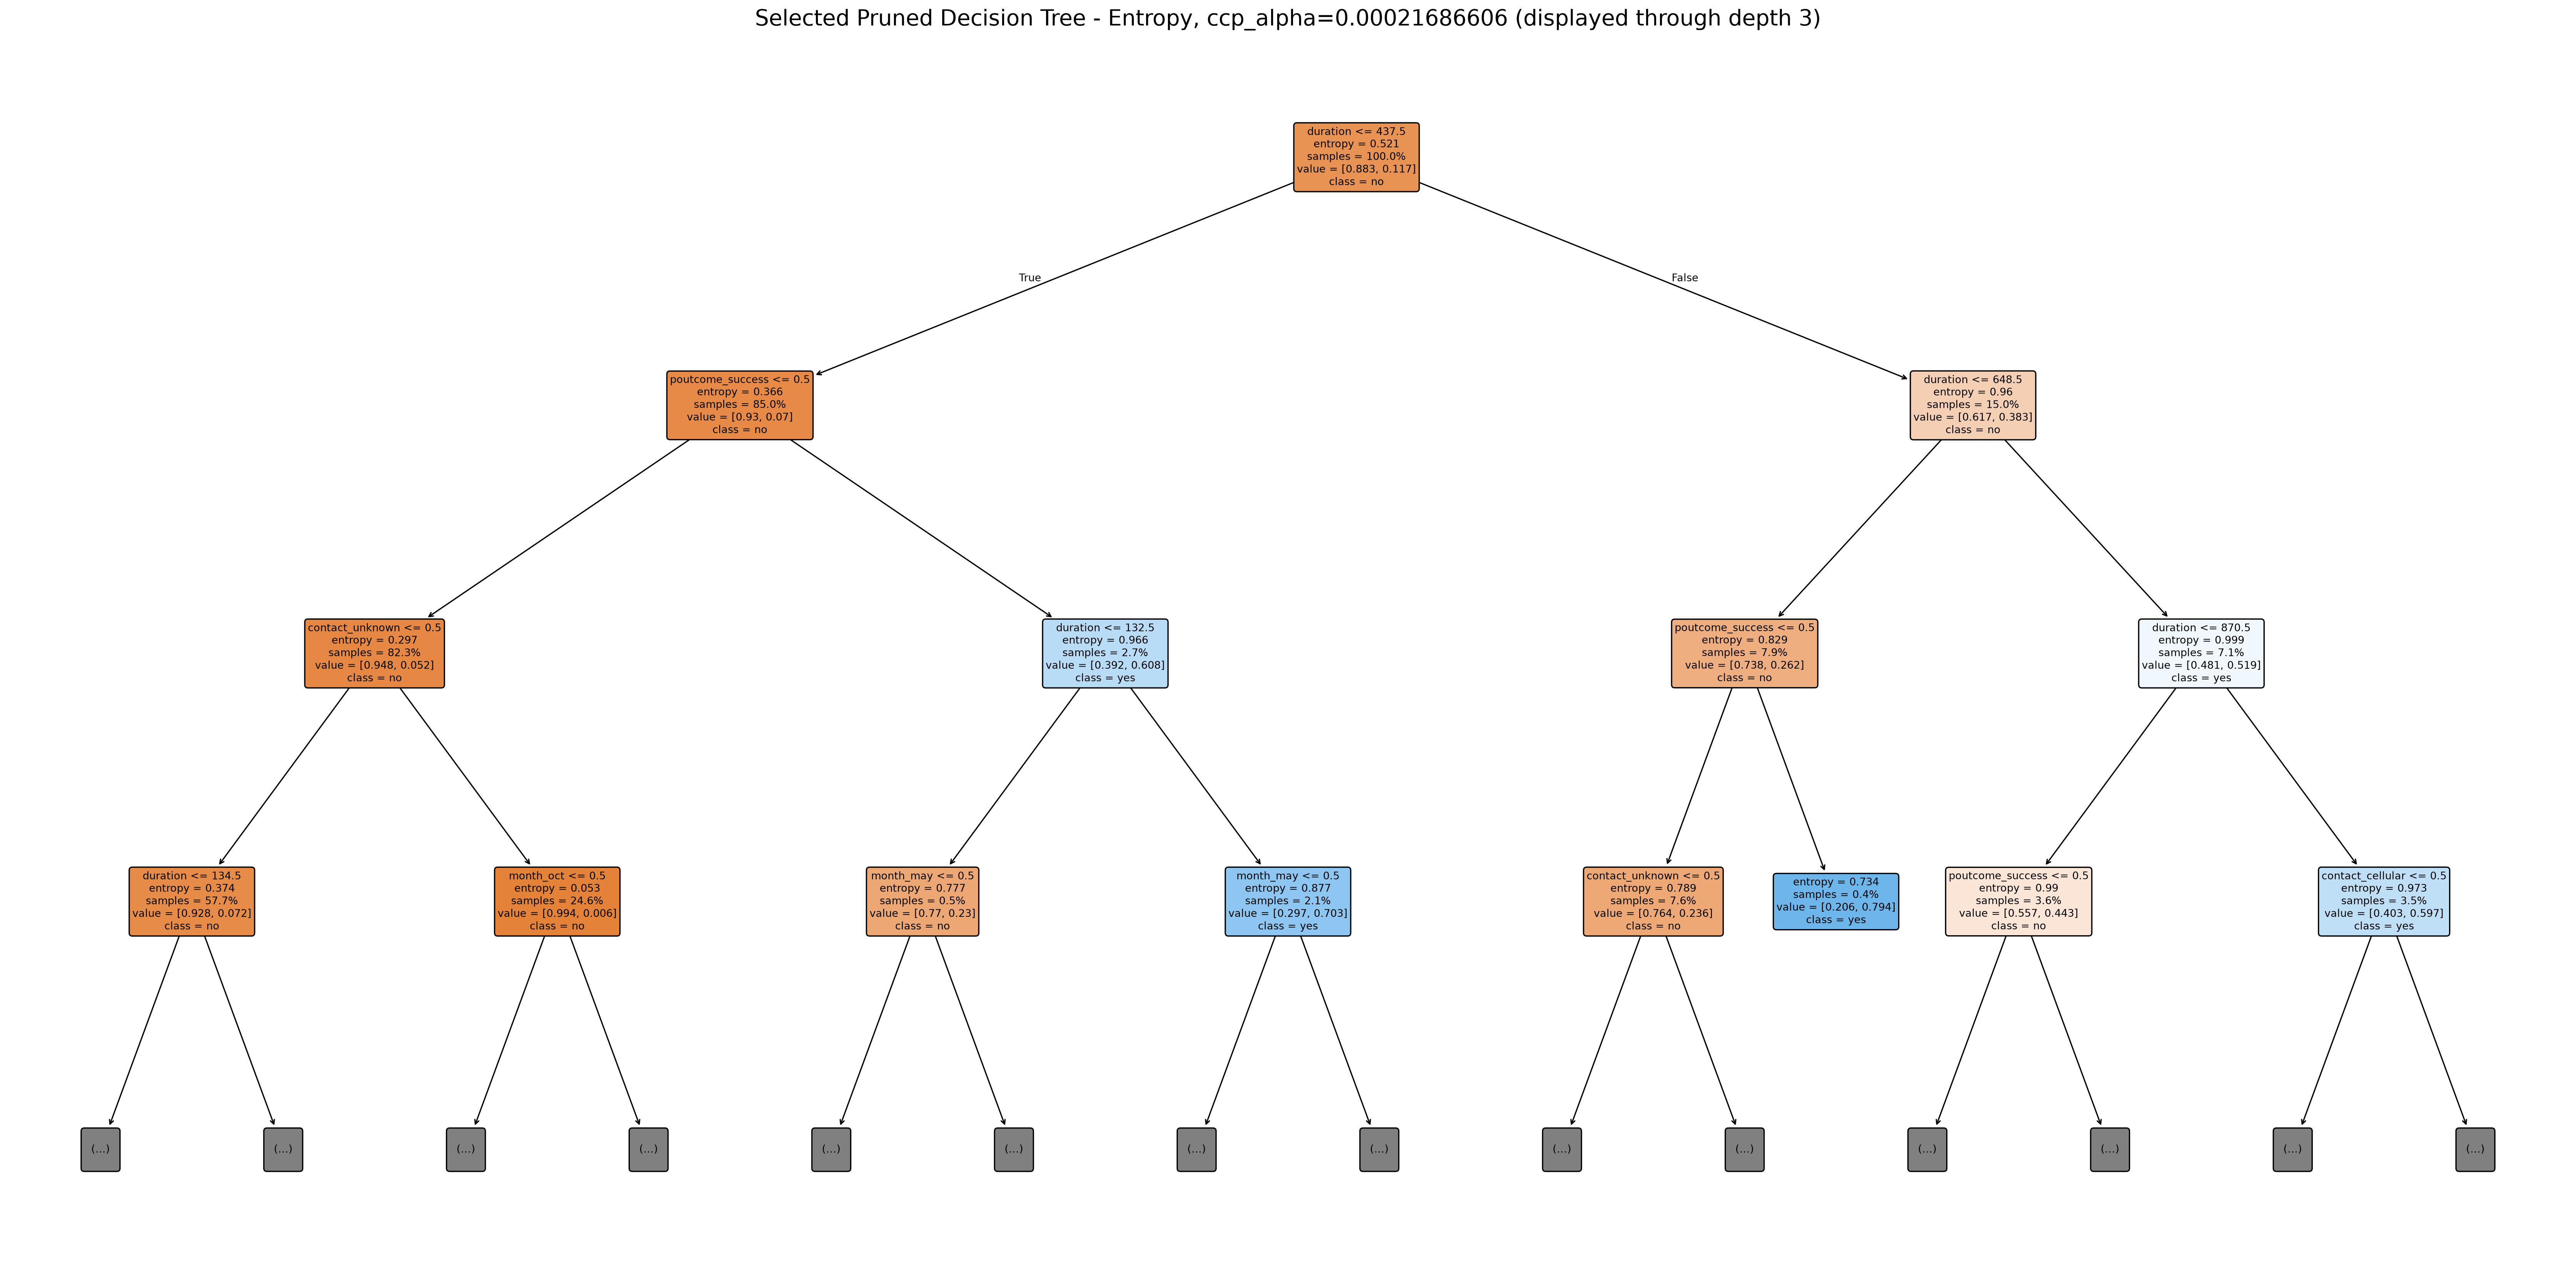

In [9]:
tree_figure = FIGURES_DIR / 'kiet_pruned_tree_top_levels.png'
display(Image(filename=str(tree_figure), width=1100))

In [10]:
baseline = comparison.loc[comparison['model'].eq('Baseline (unpruned)')].iloc[0]
pruned_gini = comparison.loc[comparison['model'].eq('Pruned Gini')].iloc[0]
pruned_entropy = comparison.loc[comparison['model'].eq('Pruned Entropy')].iloc[0]
best_test = comparison.sort_values(['accuracy', 'f1_score'], ascending=False).iloc[0]

display(Markdown(f'''## 6. Kết luận chính

- Baseline bị overfit: Accuracy train **{baseline.train_accuracy:.4f}**, Accuracy test **{baseline.accuracy:.4f}**, gap **{baseline.train_test_accuracy_gap:.4f}**.
- Pruned Gini dùng ccp_alpha **{pruned_gini.ccp_alpha:.9f}**, Accuracy test **{pruned_gini.accuracy:.4f}** và giảm số lá từ **{int(baseline.leaves):,}** xuống **{int(pruned_gini.leaves):,}**.
- Pruned Entropy đạt kết quả mô tả tốt nhất trên test: Accuracy **{pruned_entropy.accuracy:.4f}**, Error rate **{pruned_entropy.error_rate:.4f}**, F1 yes **{pruned_entropy.f1_score:.4f}**.
- Cấu hình chính được khóa bằng mean CV F1 là **{metrics_payload['selected_criterion'].title()}**; không đổi lựa chọn sau khi xem test để tránh test leakage.
- Pruning làm cây nhỏ hơn khoảng 95–96.5%, giảm variance và tăng khả năng diễn giải.
'''))

## 6. Kết luận chính

- Baseline bị overfit: Accuracy train **1.0000**, Accuracy test **0.8737**, gap **0.1263**.
- Pruned Gini dùng ccp_alpha **0.000110705**, Accuracy test **0.9005** và giảm số lá từ **2,876** xuống **101**.
- Pruned Entropy đạt kết quả mô tả tốt nhất trên test: Accuracy **0.9045**, Error rate **0.0955**, F1 yes **0.5667**.
- Cấu hình chính được khóa bằng mean CV F1 là **Entropy**; không đổi lựa chọn sau khi xem test để tránh test leakage.
- Pruning làm cây nhỏ hơn khoảng 95–96.5%, giảm variance và tăng khả năng diễn giải.
